# Per-Item Locomotive Identification — 312-Class Benchmark

This is the real task: identifying **which specific locomotive** a photo
shows (312 classes, one per `products_id`), using the 3 finalists from the
earlier 4-category architecture bake-off:

| Model | Prior test acc (4-category) | Size | Inference |
|---|---|---|---|
| EfficientNet-B0 | 90.2% | 15.6 MB | 1.06 ms |
| MobileNetV2 | 89.7% | 8.7 MB | 0.84 ms |
| CLIP ViT-B/32 (linear probe) | 81.4% | 577.2 MB | 11.98 ms |

**Important change from the previous notebook — data leakage fix:**
Each locomotive has ~5 images, but 4 of those are *synthetic augmented
variants of the same single real photo* (from `augment_dataset.py`), not
independent photos. Randomly splitting images into train/test would let
near-duplicate variants of the same real photo leak across the split,
inflating test accuracy without proving anything about real-world
generalization.

**Fix used here:** for every locomotive, the one **original real photo**
is held out as the test image. Only synthetic variants are used for
training/validation. This means test accuracy reflects performance on a
genuinely different image than what the model trained on — still not a
real phone photo, but a meaningfully fairer check than a random split.

**Also added this round:** early stopping + best-checkpoint restoration,
given the training instability seen in some models on the easier task.

**Honest limitation to keep in mind throughout:** with often just 1 real
test image per class, per-class metrics are inherently noisy (a single
class's result is binary — right or wrong — not a smooth percentage).
Real held-out phone photos, once available, are the only way to get a
trustworthy accuracy number for this feature.

**Dataset path:**
```
/kaggle/input/datasets/datascientist97/locomotive-collection-images/conductor_dataset/Locomotives
```

## 0. Setup

In [1]:
!pip install -q timm
# Deliberately NOT using --upgrade and NOT reinstalling torch/torchvision —
# Kaggle's preinstalled versions are matched to the assigned GPU. Upgrading
# them can silently break CUDA compatibility.

In [2]:
import os
import copy
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models as tvmodels

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support, log_loss,
    top_k_accuracy_score, roc_auc_score, classification_report
)

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

FORCE_CPU = False  # set True if you hit 'no kernel image available' CUDA errors
DEVICE = torch.device('cpu') if FORCE_CPU else torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)

if torch.cuda.is_available() and not FORCE_CPU:
    try:
        test_t = torch.randn(2, 2).cuda()
        _ = test_t @ test_t
        print('✅ GPU tensor op succeeded.')
    except Exception as e:
        print('❌ GPU tensor op failed — set FORCE_CPU = True above and re-run, or switch',
              'Accelerator type in Kaggle settings (e.g. P100 -> T4).')
        print('Error:', e)

Using device: cuda
✅ GPU tensor op succeeded.


In [3]:
DATASET_ROOT = "/kaggle/input/datasets/datascientist97/locomotive-collection-images/conductor_dataset/Locomotives"
IMG_SIZE = 224
BATCH_SIZE = 32
MAX_EPOCHS = 25
EARLY_STOPPING_PATIENCE = 6   # stop if val_acc doesn't improve for this many epochs
LEARNING_RATE = 1e-3

assert os.path.isdir(DATASET_ROOT), f"Not found: {DATASET_ROOT}"
print('Dataset root OK:', DATASET_ROOT)

Dataset root OK: /kaggle/input/datasets/datascientist97/locomotive-collection-images/conductor_dataset/Locomotives


## 1. Build the Leakage-Safe Train/Val/Test Split

For each `products_id` folder: the one file **without** `_aug_` in its name
is the real photo → goes to **test**. The `_aug_` files are synthetic
variants → split between train and validation. Classes with too few images
to form a valid split are skipped and logged.

In [4]:
VALID_EXTS = {'.jpg', '.jpeg', '.png', '.webp'}
MIN_TRAIN_IMAGES = 2  # need at least this many non-test images to bother training on a class

records = []
skipped_classes = []

for products_id in sorted(os.listdir(DATASET_ROOT)):
    folder = os.path.join(DATASET_ROOT, products_id)
    if not os.path.isdir(folder):
        continue

    real_files, aug_files = [], []
    for fname in sorted(os.listdir(folder)):
        ext = os.path.splitext(fname)[1].lower()
        if ext not in VALID_EXTS:
            continue
        if '_aug_' in fname:
            aug_files.append(fname)
        else:
            real_files.append(fname)

    if not real_files:
        skipped_classes.append((products_id, 'no original real photo found'))
        continue
    if len(aug_files) < MIN_TRAIN_IMAGES:
        skipped_classes.append((products_id, f'only {len(aug_files)} non-test image(s) available'))
        continue

    test_file = real_files[0]  # the real photo — held out
    records.append({'products_id': products_id, 'filename': test_file,
                     'path': os.path.join(folder, test_file), 'split': 'test'})

    # Remaining aug files: last one goes to validation, rest to train
    random.shuffle(aug_files)
    val_file = aug_files[-1]
    train_files = aug_files[:-1]

    records.append({'products_id': products_id, 'filename': val_file,
                     'path': os.path.join(folder, val_file), 'split': 'val'})
    for f in train_files:
        records.append({'products_id': products_id, 'filename': f,
                         'path': os.path.join(folder, f), 'split': 'train'})

split_df = pd.DataFrame(records)
print(f"Usable classes: {split_df['products_id'].nunique()}")
print(f"Skipped classes: {len(skipped_classes)}")
if skipped_classes:
    for pid, reason in skipped_classes[:10]:
        print(f"  {pid}: {reason}")
    if len(skipped_classes) > 10:
        print(f"  ... and {len(skipped_classes) - 10} more")
print()
print(split_df['split'].value_counts())

Usable classes: 303
Skipped classes: 0

split
train    909
test     303
val      303
Name: count, dtype: int64


In [5]:
NUM_CLASSES = split_df['products_id'].nunique()
CLASS_NAMES = sorted(split_df['products_id'].unique())
class_to_idx = {c: i for i, c in enumerate(CLASS_NAMES)}

train_df = split_df[split_df['split'] == 'train'].reset_index(drop=True)
val_df = split_df[split_df['split'] == 'val'].reset_index(drop=True)
test_df = split_df[split_df['split'] == 'test'].reset_index(drop=True)

print(f"Classes: {NUM_CLASSES}")
print(f"Train images: {len(train_df)} | Val images: {len(val_df)} | Test images: {len(test_df)}")
print(f"Avg train images per class: {len(train_df) / NUM_CLASSES:.2f}")

Classes: 303
Train images: 909 | Val images: 303 | Test images: 303
Avg train images per class: 3.00


## 2. Datasets, Transforms & DataLoaders

In [6]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.3),
    transforms.RandomRotation(4),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class LocomotiveDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row['path']).convert('RGB')
        img = self.transform(img)
        label = class_to_idx[row['products_id']]
        return img, label

train_loader = DataLoader(LocomotiveDataset(train_df, train_transform), batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(LocomotiveDataset(val_df, eval_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(LocomotiveDataset(test_df, eval_transform), batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

## 3. Model Builders — EfficientNet-B0 & MobileNetV2

CLIP is handled separately in Section 6, same as before.

In [7]:
def build_efficientnet_b0(num_classes, pretrained=True):
    weights = tvmodels.EfficientNet_B0_Weights.DEFAULT if pretrained else None
    model = tvmodels.efficientnet_b0(weights=weights)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

def build_mobilenet_v2(num_classes, pretrained=True):
    weights = tvmodels.MobileNet_V2_Weights.DEFAULT if pretrained else None
    model = tvmodels.mobilenet_v2(weights=weights)
    model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
    return model

MODEL_BUILDERS = {
    'EfficientNet-B0': build_efficientnet_b0,
    'MobileNetV2': build_mobilenet_v2,
}

## 4. Training Loop — With Early Stopping & Best-Checkpoint Restore

Trains up to `MAX_EPOCHS`, stopping early if validation accuracy hasn't
improved for `EARLY_STOPPING_PATIENCE` epochs. The best-performing epoch's
weights (by val accuracy) are restored before final test evaluation — not
just whatever the last epoch happened to be.

In [8]:
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

def model_size_mb(model):
    tmp_path = '_tmp_size_check.pt'
    torch.save(model.state_dict(), tmp_path)
    size_mb = os.path.getsize(tmp_path) / (1024 * 1024)
    os.remove(tmp_path)
    return size_mb

def measure_inference_speed(model, loader, n_batches=5):
    model.eval()
    times = []
    with torch.no_grad():
        for i, (images, _) in enumerate(loader):
            if i >= n_batches:
                break
            images = images.to(DEVICE)
            start = time.time()
            _ = model(images)
            if DEVICE.type == 'cuda':
                torch.cuda.synchronize()
            times.append((time.time() - start) / images.size(0))
    return float(np.mean(times)) * 1000 if times else float('nan')

In [9]:
def train_and_evaluate(model_name, builder_fn):
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")

    model = builder_fn(NUM_CLASSES, pretrained=True).to(DEVICE)
    total_params, trainable_params = count_params(model)

    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    criterion = nn.CrossEntropyLoss()

    history = {'train_acc': [], 'train_loss': [], 'val_acc': [], 'val_loss': []}
    best_val_acc = -1.0
    best_epoch = -1
    best_state = None
    epochs_without_improvement = 0

    start_time = time.time()
    for epoch in range(MAX_EPOCHS):
        model.train()
        running_loss, correct, total = 0.0, 0, 0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            correct += (outputs.argmax(1) == labels).sum().item()
            total += images.size(0)
        train_loss, train_acc = running_loss / total, correct / total

        model.eval()
        val_loss_total, val_correct, val_total = 0.0, 0, 0
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss_total += loss.item() * images.size(0)
                val_correct += (outputs.argmax(1) == labels).sum().item()
                val_total += images.size(0)
        val_loss, val_acc = val_loss_total / val_total, val_correct / val_total

        history['train_acc'].append(train_acc)
        history['train_loss'].append(train_loss)
        history['val_acc'].append(val_acc)
        history['val_loss'].append(val_loss)

        improved = val_acc > best_val_acc
        marker = ' *' if improved else ''
        print(f"  Epoch {epoch+1}/{MAX_EPOCHS} — train_acc: {train_acc:.3f} train_loss: {train_loss:.3f} "
              f"| val_acc: {val_acc:.3f} val_loss: {val_loss:.3f}{marker}")

        if improved:
            best_val_acc = val_acc
            best_epoch = epoch + 1
            best_state = copy.deepcopy(model.state_dict())
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
                print(f"  ⏹ Early stopping — no val improvement for {EARLY_STOPPING_PATIENCE} epochs. "
                      f"Best was epoch {best_epoch} (val_acc {best_val_acc:.3f}).")
                break

    train_time_sec = time.time() - start_time

    if best_state is not None:
        model.load_state_dict(best_state)
        print(f"  Restored best checkpoint from epoch {best_epoch}.")

    model.eval()
    all_labels, all_preds, all_probs = [], [], []
    test_loss_total = 0.0
    with torch.no_grad():
        for images, labels in test_loader:
            images_dev, labels_dev = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images_dev)
            loss = criterion(outputs, labels_dev)
            test_loss_total += loss.item() * images.size(0)
            probs = torch.softmax(outputs, dim=1).cpu().numpy()
            all_probs.extend(probs)
            all_preds.extend(outputs.argmax(1).cpu().numpy())
            all_labels.extend(labels.numpy())

    test_loss = test_loss_total / len(all_labels)
    test_acc = accuracy_score(all_labels, all_preds)
    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average='macro', zero_division=0)

    all_probs_arr = np.array(all_probs)
    k = min(3, NUM_CLASSES)
    top3_acc = top_k_accuracy_score(all_labels, all_probs_arr, k=k, labels=list(range(NUM_CLASSES)))
    try:
        roc_auc = roc_auc_score(all_labels, all_probs_arr, multi_class='ovr', average='macro')
    except Exception:
        roc_auc = float('nan')

    size_mb = model_size_mb(model)
    inference_ms = measure_inference_speed(model, test_loader)

    per_class_report = classification_report(
        all_labels, all_preds, target_names=[str(c) for c in CLASS_NAMES],
        output_dict=True, zero_division=0)

    result = {
        'model_name': model_name, 'total_params': total_params, 'trainable_params': trainable_params,
        'model_size_mb': size_mb, 'train_time_sec': train_time_sec, 'inference_ms_per_image': inference_ms,
        'best_epoch': best_epoch, 'epochs_run': len(history['train_acc']),
        'train_acc': history['train_acc'][best_epoch - 1] if best_epoch > 0 else history['train_acc'][-1],
        'train_loss': history['train_loss'][best_epoch - 1] if best_epoch > 0 else history['train_loss'][-1],
        'val_acc': best_val_acc,
        'val_loss': history['val_loss'][best_epoch - 1] if best_epoch > 0 else history['val_loss'][-1],
        'test_acc': test_acc, 'test_loss': test_loss,
        'precision_macro': precision, 'recall_macro': recall, 'f1_macro': f1,
        'top3_acc': top3_acc, 'roc_auc_macro': roc_auc,
    }

    return result, history, per_class_report

## 5. Train Both CNN Models

In [10]:
all_results = []
all_histories = {}
all_per_class_reports = {}

for model_name, builder_fn in MODEL_BUILDERS.items():
    result, history, per_class_report = train_and_evaluate(model_name, builder_fn)
    all_results.append(result)
    all_histories[model_name] = history
    all_per_class_reports[model_name] = per_class_report
    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

print('\n✅ Both CNN models trained.')


Training: EfficientNet-B0
Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 134MB/s] 


  Epoch 1/25 — train_acc: 0.105 train_loss: 5.403 | val_acc: 0.426 val_loss: 3.672 *
  Epoch 2/25 — train_acc: 0.431 train_loss: 3.141 | val_acc: 0.809 val_loss: 1.351 *
  Epoch 3/25 — train_acc: 0.767 train_loss: 1.203 | val_acc: 0.884 val_loss: 0.440 *
  Epoch 4/25 — train_acc: 0.883 train_loss: 0.508 | val_acc: 0.898 val_loss: 0.329 *
  Epoch 5/25 — train_acc: 0.890 train_loss: 0.400 | val_acc: 0.901 val_loss: 0.322 *
  Epoch 6/25 — train_acc: 0.920 train_loss: 0.292 | val_acc: 0.927 val_loss: 0.245 *
  Epoch 7/25 — train_acc: 0.942 train_loss: 0.245 | val_acc: 0.941 val_loss: 0.226 *
  Epoch 8/25 — train_acc: 0.936 train_loss: 0.264 | val_acc: 0.957 val_loss: 0.144 *
  Epoch 9/25 — train_acc: 0.959 train_loss: 0.154 | val_acc: 0.960 val_loss: 0.128 *
  Epoch 10/25 — train_acc: 0.957 train_loss: 0.175 | val_acc: 0.947 val_loss: 0.178
  Epoch 11/25 — train_acc: 0.965 train_loss: 0.149 | val_acc: 0.954 val_loss: 0.167
  Epoch 12/25 — train_acc: 0.965 train_loss: 0.131 | val_acc: 0.960

100%|██████████| 13.6M/13.6M [00:00<00:00, 112MB/s] 


  Epoch 1/25 — train_acc: 0.063 train_loss: 5.571 | val_acc: 0.333 val_loss: 4.117 *
  Epoch 2/25 — train_acc: 0.415 train_loss: 3.030 | val_acc: 0.825 val_loss: 1.296 *
  Epoch 3/25 — train_acc: 0.793 train_loss: 0.950 | val_acc: 0.884 val_loss: 0.434 *
  Epoch 4/25 — train_acc: 0.883 train_loss: 0.397 | val_acc: 0.921 val_loss: 0.246 *
  Epoch 5/25 — train_acc: 0.925 train_loss: 0.272 | val_acc: 0.941 val_loss: 0.173 *
  Epoch 6/25 — train_acc: 0.952 train_loss: 0.186 | val_acc: 0.960 val_loss: 0.128 *
  Epoch 7/25 — train_acc: 0.953 train_loss: 0.143 | val_acc: 0.950 val_loss: 0.111
  Epoch 8/25 — train_acc: 0.968 train_loss: 0.118 | val_acc: 0.937 val_loss: 0.194
  Epoch 9/25 — train_acc: 0.961 train_loss: 0.166 | val_acc: 0.967 val_loss: 0.128 *
  Epoch 10/25 — train_acc: 0.961 train_loss: 0.139 | val_acc: 0.957 val_loss: 0.128
  Epoch 11/25 — train_acc: 0.986 train_loss: 0.088 | val_acc: 0.983 val_loss: 0.083 *
  Epoch 12/25 — train_acc: 0.982 train_loss: 0.080 | val_acc: 0.974 v

## 6. CLIP (ViT-B/32) — Frozen Embeddings + Linear Probe

Same paradigm as the previous notebook: frozen CLIP image encoder converts
each photo to an embedding, then a Logistic Regression classifies among
the 312 classes. No epochs, no early stopping needed — this 'trains' in
one shot.

In [11]:
from transformers import CLIPModel, CLIPProcessor

clip_model_name = 'openai/clip-vit-base-patch32'
clip_model = CLIPModel.from_pretrained(clip_model_name).to(DEVICE)
clip_processor = CLIPProcessor.from_pretrained(clip_model_name)
clip_model.eval()

def get_pooled_features(output):
    """Handles whatever shape get_image_features() returns across
    different transformers versions."""
    if isinstance(output, torch.Tensor):
        return output
    if hasattr(output, 'image_embeds') and output.image_embeds is not None:
        return output.image_embeds
    if hasattr(output, 'pooler_output') and output.pooler_output is not None:
        return output.pooler_output
    if hasattr(output, 'last_hidden_state'):
        return output.last_hidden_state.mean(dim=1)
    raise TypeError(f"Unrecognized CLIP output type: {type(output)}")

def extract_clip_embeddings(df):
    embeddings, labels = [], []
    batch_size = 32
    paths = df['path'].tolist()
    pids = df['products_id'].tolist()
    for i in range(0, len(paths), batch_size):
        batch_paths = paths[i:i+batch_size]
        batch_pids = pids[i:i+batch_size]
        images = [Image.open(p).convert('RGB') for p in batch_paths]
        inputs = clip_processor(images=images, return_tensors='pt').to(DEVICE)
        with torch.no_grad():
            raw_output = clip_model.get_image_features(**inputs)
            feats = get_pooled_features(raw_output)
        embeddings.extend(feats.cpu().numpy())
        labels.extend([class_to_idx[p] for p in batch_pids])
    return np.array(embeddings), np.array(labels)

config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-base-patch32
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
text_model.embeddings.position_ids   | UNEXPECTED |  | 
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

In [12]:
clip_start = time.time()
print('Extracting CLIP embeddings for train/val/test...')
X_train, y_train = extract_clip_embeddings(train_df)
X_val, y_val = extract_clip_embeddings(val_df)
X_test, y_test = extract_clip_embeddings(test_df)
embedding_time = time.time() - clip_start
print(f"Embedding extraction took {embedding_time:.1f}s for "
      f"{len(X_train)+len(X_val)+len(X_test)} images total.")

Extracting CLIP embeddings for train/val/test...
Embedding extraction took 8.4s for 1515 images total.


In [13]:
clip_head = LogisticRegression(max_iter=3000, multi_class='auto')

head_start = time.time()
clip_head.fit(X_train, y_train)
clip_train_time = time.time() - head_start + embedding_time

test_preds = clip_head.predict(X_test)
test_probs = clip_head.predict_proba(X_test)

clip_test_acc = accuracy_score(y_test, test_preds)
clip_test_loss = log_loss(y_test, test_probs, labels=list(range(NUM_CLASSES)))
clip_precision, clip_recall, clip_f1, _ = precision_recall_fscore_support(
    y_test, test_preds, average='macro', zero_division=0)
clip_top3 = top_k_accuracy_score(y_test, test_probs, k=min(3, NUM_CLASSES), labels=list(range(NUM_CLASSES)))
try:
    clip_roc_auc = roc_auc_score(y_test, test_probs, multi_class='ovr', average='macro')
except Exception:
    clip_roc_auc = float('nan')

val_preds = clip_head.predict(X_val)
clip_val_acc = accuracy_score(y_val, val_preds)
train_preds = clip_head.predict(X_train)
clip_train_acc = accuracy_score(y_train, train_preds)

sample_imgs = [Image.open(p).convert('RGB') for p in test_df['path'].tolist()[:16]]
inf_start = time.time()
inputs = clip_processor(images=sample_imgs, return_tensors='pt').to(DEVICE)
with torch.no_grad():
    raw_output = clip_model.get_image_features(**inputs)
    feats = get_pooled_features(raw_output)
_ = clip_head.predict(feats.cpu().numpy())
clip_inference_ms = (time.time() - inf_start) / len(sample_imgs) * 1000

clip_result = {
    'model_name': 'CLIP ViT-B/32 (linear probe)',
    'total_params': sum(p.numel() for p in clip_model.parameters()),
    'trainable_params': X_train.shape[1] * NUM_CLASSES,
    'model_size_mb': model_size_mb(clip_model),
    'train_time_sec': clip_train_time,
    'inference_ms_per_image': clip_inference_ms,
    'best_epoch': 1, 'epochs_run': 1,
    'train_acc': clip_train_acc, 'train_loss': float('nan'),
    'val_acc': clip_val_acc, 'val_loss': float('nan'),
    'test_acc': clip_test_acc, 'test_loss': clip_test_loss,
    'precision_macro': clip_precision, 'recall_macro': clip_recall, 'f1_macro': clip_f1,
    'top3_acc': clip_top3, 'roc_auc_macro': clip_roc_auc,
}
all_results.append(clip_result)
print('✅ CLIP evaluation complete. Test accuracy:', round(clip_test_acc, 3))

✅ CLIP evaluation complete. Test accuracy: 0.977


## 7. Results Table — All 3 Approaches

In [14]:
results_df = pd.DataFrame(all_results).sort_values('test_acc', ascending=False).reset_index(drop=True)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)
results_df.round(4)

,model_name,total_params,trainable_params,model_size_mb,train_time_sec,inference_ms_per_image,best_epoch,epochs_run,train_acc,train_loss,val_acc,val_loss,test_acc,test_loss,precision_macro,recall_macro,f1_macro,top3_acc,roc_auc_macro
0,MobileNetV2,2612015,2612015,10.1998,82.7289,0.8538,11,17,0.9857,0.0884,0.9835,0.0829,0.9802,0.0585,0.9703,0.9802,0.9736,1.0,1.0
1,EfficientNet-B0,4395691,4395691,17.0556,114.0501,1.0905,13,19,0.9659,0.1465,0.9736,0.1011,0.9769,0.0761,0.9653,0.9769,0.9692,1.0,1.0
2,CLIP ViT-B/32 (linear probe),151277313,155136,577.2275,23.8399,10.3773,1,1,1.0000,NaN,0.9274,NaN,0.9769,0.4210,0.9653,0.9769,0.9692,1.0,1.0


In [15]:
results_df.to_csv('per_item_model_comparison_results.csv', index=False)
print('Saved results to per_item_model_comparison_results.csv')

Saved results to per_item_model_comparison_results.csv


## 8. Weakest Locomotives — Per-Class Breakdown (CNN Models)

With only 1 real test photo per class, each class's result is binary
(right/wrong) — but this still tells you exactly which locomotives need
real reshoot photos most, same idea as Azure's per-tag report.

In [16]:
for model_name, report in all_per_class_reports.items():
    report_df = pd.DataFrame(report).transpose()
    class_rows = report_df.iloc[:NUM_CLASSES]
    weakest = class_rows[class_rows['f1-score'] == 0].sort_values('support', ascending=False)
    print(f"\n--- {model_name}: {len(weakest)} locomotives misidentified out of {NUM_CLASSES} ---")
    if len(weakest) > 0:
        print(weakest.index.tolist()[:30])


--- EfficientNet-B0: 7 locomotives misidentified out of 303 ---
['1098', '1526', '1767', '1803', '1808', '1846', '1865']

--- MobileNetV2: 6 locomotives misidentified out of 303 ---
['1212', '1786', '1800', '1844', '1846', '1898']


## 9. Training Curves (CNN Models Only)

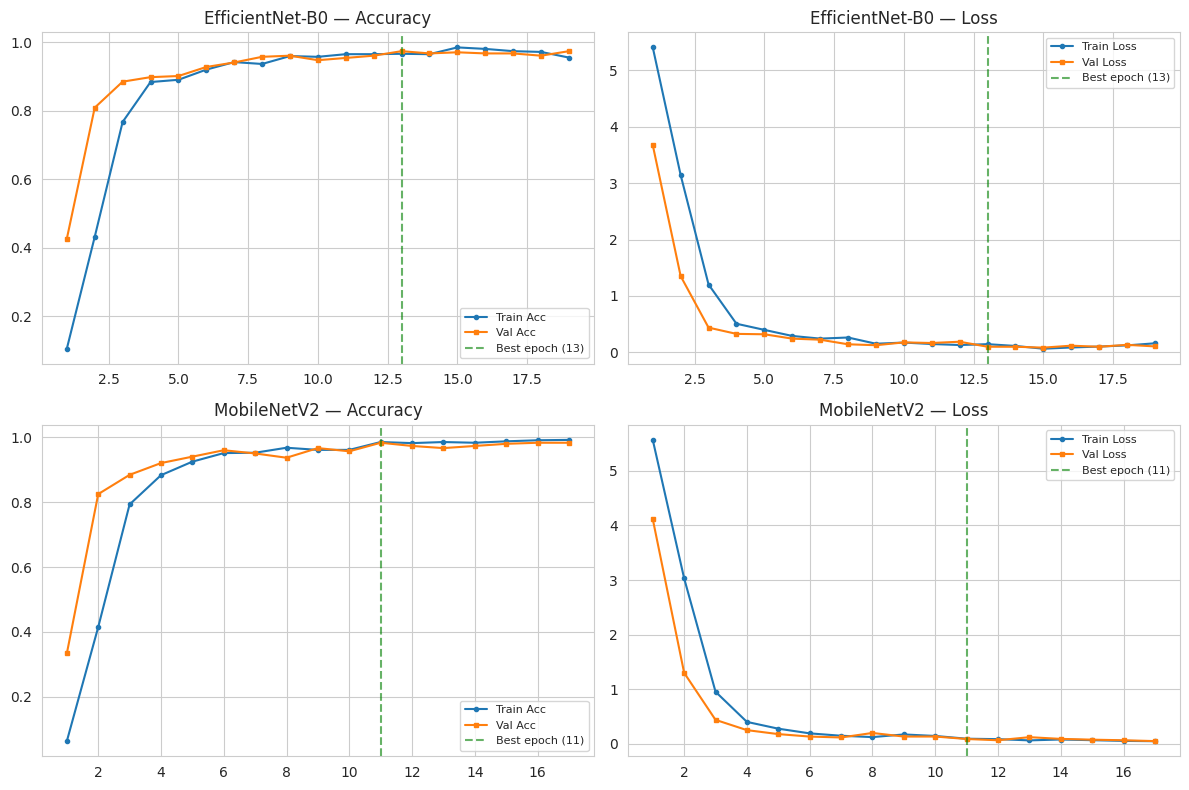

In [17]:
fig, axes = plt.subplots(len(all_histories), 2, figsize=(12, 4 * len(all_histories)))
if len(all_histories) == 1:
    axes = axes.reshape(1, -1)

for i, (model_name, history) in enumerate(all_histories.items()):
    epochs_range = range(1, len(history['train_acc']) + 1)
    best_ep = results_df[results_df['model_name'] == model_name]['best_epoch'].values[0]

    axes[i, 0].plot(epochs_range, history['train_acc'], label='Train Acc', marker='o', markersize=3)
    axes[i, 0].plot(epochs_range, history['val_acc'], label='Val Acc', marker='s', markersize=3)
    axes[i, 0].axvline(best_ep, color='green', linestyle='--', alpha=0.6, label=f'Best epoch ({best_ep})')
    axes[i, 0].set_title(f'{model_name} — Accuracy')
    axes[i, 0].legend(fontsize=8)

    axes[i, 1].plot(epochs_range, history['train_loss'], label='Train Loss', marker='o', markersize=3)
    axes[i, 1].plot(epochs_range, history['val_loss'], label='Val Loss', marker='s', markersize=3)
    axes[i, 1].axvline(best_ep, color='green', linestyle='--', alpha=0.6, label=f'Best epoch ({best_ep})')
    axes[i, 1].set_title(f'{model_name} — Loss')
    axes[i, 1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## 10. Final Comparison — Radar Chart & Weighted Leaderboard

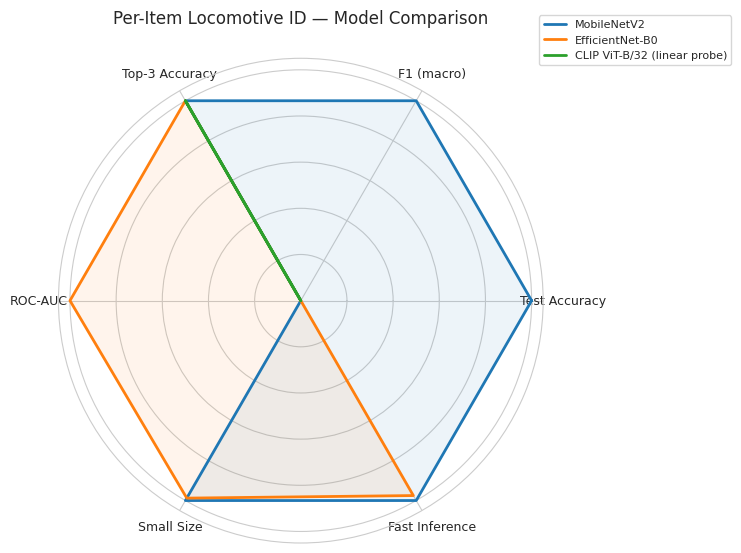

In [18]:
radar_metrics = {
    'Test Accuracy': ('test_acc', False),
    'F1 (macro)': ('f1_macro', False),
    'Top-3 Accuracy': ('top3_acc', False),
    'ROC-AUC': ('roc_auc_macro', False),
    'Small Size': ('model_size_mb', True),
    'Fast Inference': ('inference_ms_per_image', True),
}

radar_df = results_df.set_index('model_name')
normalized = pd.DataFrame(index=radar_df.index)
for label, (col, invert) in radar_metrics.items():
    values = radar_df[col].fillna(radar_df[col].median())
    vmin, vmax = values.min(), values.max()
    normalized[label] = 1.0 if vmax == vmin else ((1 - (values - vmin) / (vmax - vmin)) if invert else (values - vmin) / (vmax - vmin))

labels = list(radar_metrics.keys())
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
colors = sns.color_palette('tab10', len(normalized))
for i, (model_name, row) in enumerate(normalized.iterrows()):
    values = row.tolist(); values += values[:1]
    ax.plot(angles, values, label=model_name, color=colors[i], linewidth=2)
    ax.fill(angles, values, color=colors[i], alpha=0.08)
ax.set_xticks(angles[:-1]); ax.set_xticklabels(labels, fontsize=9)
ax.set_yticklabels([])
ax.set_title('Per-Item Locomotive ID — Model Comparison', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=8)
plt.tight_layout()
plt.show()

In [19]:
def minmax_norm(series, invert=False):
    vmin, vmax = series.min(), series.max()
    if vmax == vmin:
        return pd.Series(1.0, index=series.index)
    norm = (series - vmin) / (vmax - vmin)
    return (1 - norm) if invert else norm

score_df = results_df.copy()
score_df['norm_acc'] = minmax_norm(score_df['test_acc'])
score_df['norm_f1'] = minmax_norm(score_df['f1_macro'])
score_df['norm_size'] = minmax_norm(score_df['model_size_mb'], invert=True)
score_df['norm_speed'] = minmax_norm(score_df['inference_ms_per_image'], invert=True)
score_df['weighted_score'] = (0.50*score_df['norm_acc'] + 0.20*score_df['norm_f1'] +
                                0.15*score_df['norm_size'] + 0.15*score_df['norm_speed'])

leaderboard = score_df.sort_values('weighted_score', ascending=False)
leaderboard[['model_name', 'test_acc', 'top3_acc', 'f1_macro', 'model_size_mb',
             'inference_ms_per_image', 'weighted_score']].round(4)

,model_name,test_acc,top3_acc,f1_macro,model_size_mb,inference_ms_per_image,weighted_score
0,MobileNetV2,0.9802,1.0,0.9736,10.1998,0.8538,1.0000
1,EfficientNet-B0,0.9769,1.0,0.9692,17.0556,1.0905,0.2945
2,CLIP ViT-B/32 (linear probe),0.9769,1.0,0.9692,577.2275,10.3773,0.0000


In [20]:
winner = leaderboard.iloc[0]
print('='*60)
print('RECOMMENDATION — Per-Item (312-class) Locomotive Identification')
print('='*60)
print(f"Best overall: {winner['model_name']}")
print(f"  Test accuracy (1 real photo/class): {winner['test_acc']:.3f}")
print(f"  Top-3 accuracy:                     {winner['top3_acc']:.3f}")
print(f"  Model size:                          {winner['model_size_mb']:.1f} MB")
print(f"  Inference speed:                     {winner['inference_ms_per_image']:.2f} ms/image")
print()
print('IMPORTANT: test accuracy here is measured against exactly one held-out')
print('real photo per class — a genuine but still limited check. The real test')
print('is real-world phone photos once available (Step 6 of the build plan).')
print('Top-3 accuracy is arguably the more meaningful number at this data scale —')
print("it's what powers the confidence-threshold 'top matches' fallback in the")
print('actual Zen Cart integration.')

RECOMMENDATION — Per-Item (312-class) Locomotive Identification
Best overall: MobileNetV2
  Test accuracy (1 real photo/class): 0.980
  Top-3 accuracy:                     1.000
  Model size:                          10.2 MB
  Inference speed:                     0.85 ms/image

IMPORTANT: test accuracy here is measured against exactly one held-out
real photo per class — a genuine but still limited check. The real test
is real-world phone photos once available (Step 6 of the build plan).
Top-3 accuracy is arguably the more meaningful number at this data scale —
it's what powers the confidence-threshold 'top matches' fallback in the
actual Zen Cart integration.
